In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils

2025-10-27 17:51:59.241142: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 17:51:59.241533: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 17:51:59.306674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 17:52:25.511836: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# when functions changed
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

# GEX

In [3]:
data_path = "/ix1/ylee/Yifan_Zhang/Code_data/external/GSE188320 Th17"
mdata = mu.read(data_path + "/GSE188320_batch6_9_gex_tcr.h5mu")
mdata

MuData object with n_obs × n_vars = 39845 × 27998
  2 modalities
    gex:	39845 x 27998
      obs:	'batch', 'condition', 'mouse_id', 'assignment_demuxem'
    airr:	39845 x 0
      obsm:	'airr'

In [4]:
%cd $data_path

/ix1/ylee/Yifan_Zhang/Code_data/external/GSE188320 Th17


In [24]:
mdata.obs['GSE'] = 'GSE188320'
mdata.obs['GSM'] = mdata['gex'].obs['batch']
mdata.obs['condition'] = mdata['gex'].obs['condition']

mdata['gex'].obs.rename(columns = {"mouse_id":"sample_id", "assignment_demuxem":"tissue"}, inplace=True)
mdata['gex'].obs['tissue'] = (mdata['gex'].obs['tissue'].replace({'CN': 'CNS', 'SPL': 'Spleen'}))
mdata.obs['tissue'] = mdata['gex'].obs['tissue']

# mdata['gex'].obs['cell_type'] = 'Th17'


In [25]:
mdata.obs['tissue'].value_counts()

tissue
Spleen    9578
COL       5092
PP        4930
SI        4201
DLN       2479
MLN       1720
CNS       1431
Name: count, dtype: int64

In [7]:
genes = [g for g in mdata.var_names if g.startswith('Il17')]
genes

['Il17a',
 'Il17f',
 'Il17re',
 'Il17rc',
 'Il17ra',
 'Il17c',
 'Il17rd',
 'Il17rb',
 'Il17d',
 'Il17b']

In [8]:
mdata = mdata_utils.pp_EAE(mdata, celltype_score = 0.4, cellstate_score = 0.4, topN_variable = None)

In [9]:
print(mdata['gex'].obs['cell_type'].value_counts())
print(mdata['gex'].obs['state'].value_counts())

cell_type
CD4     3955
Th17    2743
Treg    2675
CD8     2508
Name: count, dtype: int64
state
Exhaust       3812
Activation    2780
Mem_Naive     2008
IFN_stim      1388
Name: count, dtype: int64


# TCR

In [10]:
# mdata = mdata_ori.copy()
mdata['airr'].obs['sample_id'] = mdata.obs['sample_id']

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only", within_group = 'sample_id')

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

df2_filtered = meta_airr.loc[:, ~meta_airr.columns.isin(mdata.obs.columns)]
mdata.obs = mdata.obs.join(df2_filtered)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
ir.tl.clonal_expansion(mdata)


In [11]:
mdata

MuData object with n_obs × n_vars = 39845 × 12800
  obs:	'GSE', 'GSM', 'condition', 'tissue', 'state', 'cell_type', 'sample_id', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	39758 x 12800
      obs:	'batch', 'condition', 'sample_id', 'assignment_demuxem', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	39845 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [12]:
count = (mdata['airr'].obs['clone_id_size'] == 1).sum()
print(count)

10860


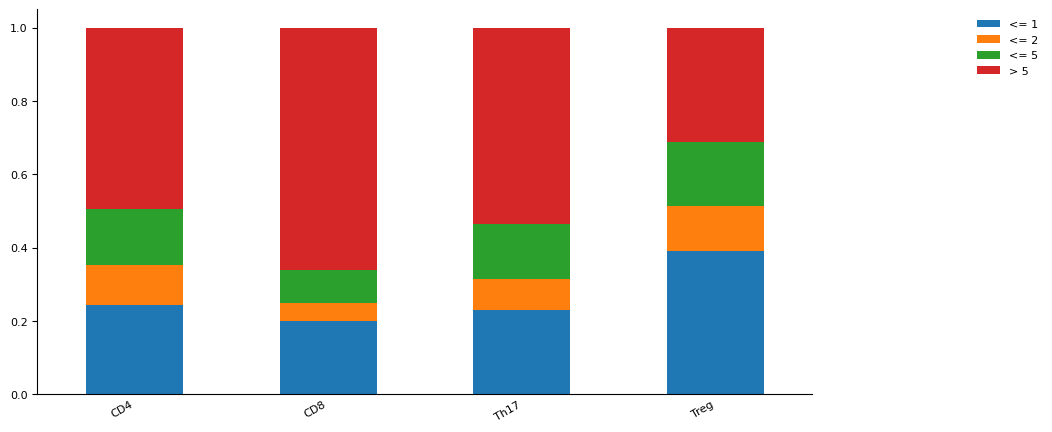

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="cell_type",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

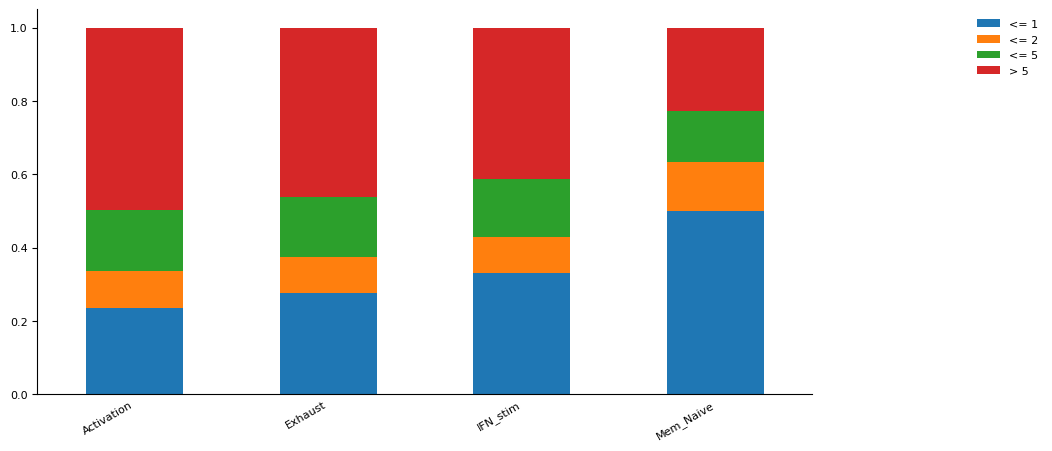

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="state",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

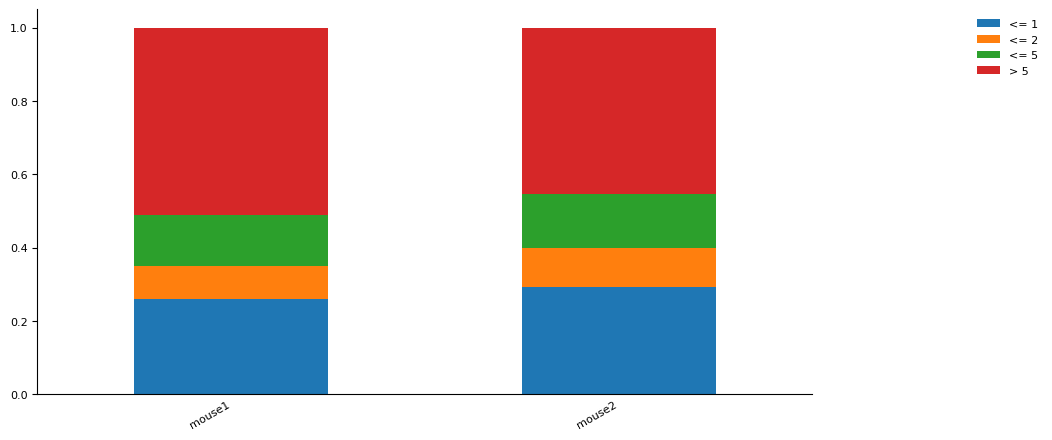

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'sample_id',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

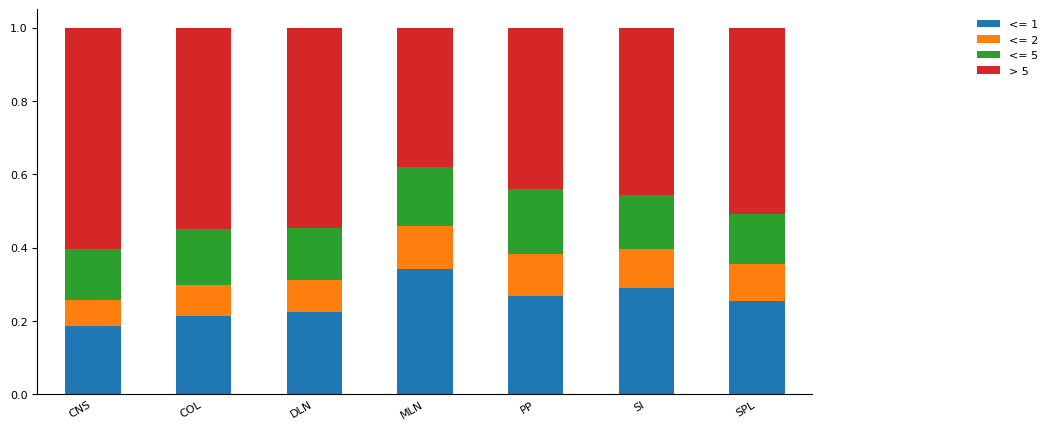

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'tissue',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

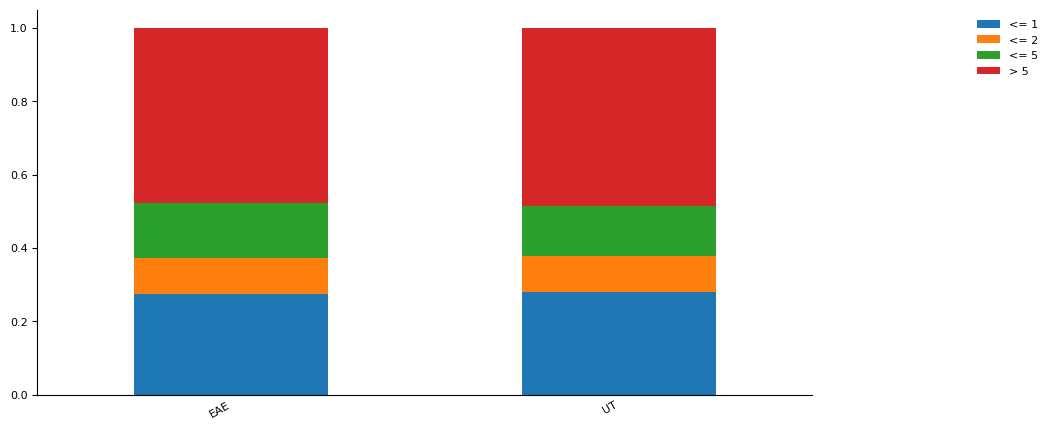

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'condition',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

In [22]:
mdata.obs['tissue']

AAACCTGAGAGTCGGT-1-b6m1    NaN
AAACCTGAGGCTCAGA-1-b6m1    MLN
AAACCTGCAATAGCAA-1-b6m1    SPL
AAACCTGCAGTCTTCC-1-b6m1    COL
AAACCTGCATTCTTAC-1-b6m1    SPL
                          ... 
CTAGAGTCAGTCGATT-1-b9m2    MLN
GAACGGATCTGGTGTA-1-b9m2    COL
GAATGAACAGGGAGAG-1-b9m2    SPL
GACTACATCATCTGTT-1-b9m2    SPL
GATCGATCAGACTCGC-1-b9m2    SPL
Name: tissue, Length: 39845, dtype: category
Categories (7, object): ['CNS', 'COL', 'DLN', 'MLN', 'PP', 'SI', 'SPL']

In [26]:
# mdata.write('yz_processed_allGenes_annotateByRef.h5mu')
mdata.write('yz_processed_allGenes_annotateByScore.h5mu')

In [19]:
aa

NameError: name 'aa' is not defined

In [ ]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
sc.pl.umap(mdata["gex"], color=['batch', 'sample_id', 'state', 'assignment_demuxem', 'condition'], ncols=2,)